In [64]:
!python --version

Python 3.11.9


In [65]:
%matplotlib inline

In [66]:
import os

def define_auth():
    os.environ["HF_TOKEN"] = ""

In [67]:
import pandas as pd

def get_dataset(type="train"):
    splits = {'train': 'train_meta.csv', 'test': 'test_meta.csv'}
    df = pd.read_csv("hf://datasets/lasfk/EEG-fNIRS-based-Handwriting-Trajectory-Dataset/" + splits[type])
    return df

In [68]:
FNIRS_CHANNELS = [
    "fnirs_1",
    "fnirs_2",
    "fnirs_3",
    "fnirs_4",
    "fnirs_5",
    "fnirs_6",
    "fnirs_7",
    "fnirs_8"
]
FNIRS_FS = 64

In [69]:
import pandas as pd

def read_fnirs(subject, session):
    path = f"datasets/raw/{subject}/fNIRS/{session}.csv"
    fnirs = pd.read_csv(path)
    return fnirs

In [70]:
import numpy as np

from scipy.signal import butter
from scipy.stats import median_abs_deviation
from sklearn.decomposition import PCA

from scipy.signal import butter
from scipy.signal import sosfiltfilt

def bandpass_fnirs(
    signal,
    fs=64,
    lowcut=0.01,
    highcut=0.3,
    order=4
):

    # -----------------------------------------------------
    # CLEAN NaN
    # -----------------------------------------------------

    signal = np.nan_to_num(
        signal,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # -----------------------------------------------------
    # NORMALIZED FREQUENCY
    # -----------------------------------------------------

    nyquist = fs / 2

    low = lowcut / nyquist
    high = highcut / nyquist

    # -----------------------------------------------------
    # SOS FILTER
    # -----------------------------------------------------

    sos = butter(
        order,
        [low, high],
        btype="bandpass",
        output="sos"
    )

    # -----------------------------------------------------
    # FILTER
    # -----------------------------------------------------

    filtered = sosfiltfilt(
        sos,
        signal
    )

    # -----------------------------------------------------
    # CLEAN AGAIN
    # -----------------------------------------------------

    filtered = np.nan_to_num(
        filtered,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return filtered

# =========================================================
# MOTION ARTIFACT CORRECTION
# ROBUST METHOD
# =========================================================

def robust_clip(
    signal,
    threshold=5.0
):

    median = np.median(signal)

    mad = median_abs_deviation(
        signal
    )

    if mad == 0:
        mad = 1e-8

    robust_z = (
        signal - median
    ) / mad

    # -----------------------------------------------------
    # CLIP EXTREME OUTLIER
    # -----------------------------------------------------

    clipped = signal.copy()

    clipped[
        np.abs(robust_z) > threshold
    ] = median

    return clipped

# =========================================================
# NORMALIZATION
# =========================================================

def normalize_fnirs(
    fnirs_data
):

    normalized = np.zeros_like(
        fnirs_data
    )

    for ch in range(fnirs_data.shape[0]):

        signal = fnirs_data[ch]

        mean = signal.mean()
        std = signal.std()

        if std == 0:
            std = 1e-8

        normalized[ch] = (
            signal - mean
        ) / std

    return normalized

# =========================================================
# FULL PREPROCESSING
# =========================================================

def preprocess_fnirs(
    fnirs_data,
    fs=64
):

    # shape:
    # (channels, times)

    processed = fnirs_data.copy()

    # =====================================================
    # CHANNEL LOOP
    # =====================================================

    for ch in range(processed.shape[0]):

        signal = processed[ch]

        # -------------------------------------------------
        # BANDPASS
        # 0.01 - 0.3 Hz
        # -------------------------------------------------

        signal = bandpass_fnirs(
            signal,
            fs=fs,
            lowcut=0.01,
            highcut=0.3
        )

        # -------------------------------------------------
        # ROBUST MOTION ARTIFACT REDUCTION
        # -------------------------------------------------

        signal = robust_clip(
            signal,
            threshold=5
        )

        processed[ch] = signal

    # =====================================================
    # NORMALIZATION
    # =====================================================

    processed = normalize_fnirs(
        processed
    )

    return processed

In [71]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

# =========================================================
# PCA ANALYSIS FOR FNIRS
# =========================================================

def analyze_fnirs_pca(fnirs_data):

    # shape:
    # (channels, times)

    print("Input shape:")
    print(fnirs_data.shape)

    # =====================================================
    # PCA
    # =====================================================

    pca = PCA(
        n_components=fnirs_data.shape[0]
    )

    transformed = pca.fit_transform(
        fnirs_data.T
    )

    # shape:
    # (times, components)

    explained = pca.explained_variance_ratio_

    # =====================================================
    # PRINT EXPLAINED VARIANCE
    # =====================================================

    print("\nExplained Variance Ratio:")

    for i, ratio in enumerate(explained):

        print(
            f"PC{i+1}: {ratio:.4f}"
        )

    # =====================================================
    # PLOT EXPLAINED VARIANCE
    # =====================================================

    plt.figure(figsize=(10, 5))

    plt.bar(
        np.arange(1, len(explained)+1),
        explained
    )

    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")

    plt.title(
        "PCA Explained Variance"
    )

    plt.grid()

    plt.show()

    # =====================================================
    # PLOT PC1
    # =====================================================

    plt.figure(figsize=(14, 5))

    plt.plot(
        transformed[:, 0]
    )

    plt.title(
        "First Principal Component (PC1)"
    )

    plt.xlabel("Time")
    plt.ylabel("Amplitude")

    plt.grid()

    plt.show()

    # =====================================================
    # GLOBAL MEAN SIGNAL
    # =====================================================

    global_signal = fnirs_data.mean(axis=0)

    plt.figure(figsize=(14, 5))

    plt.plot(
        global_signal,
        label="Global Mean Signal"
    )

    plt.plot(
        transformed[:, 0],
        label="PC1",
        alpha=0.7
    )

    plt.title(
        "Global Signal vs PC1"
    )

    plt.xlabel("Time")
    plt.ylabel("Amplitude")

    plt.legend()

    plt.grid()

    plt.show()

    # =====================================================
    # CHANNEL SYNCHRONY
    # =====================================================

    corr = np.corrcoef(
        fnirs_data
    )

    plt.figure(figsize=(8, 6))

    plt.imshow(
        corr,
        aspect="auto"
    )

    plt.colorbar()

    plt.title(
        "Channel Correlation Matrix"
    )

    plt.xlabel("Channel")
    plt.ylabel("Channel")

    plt.show()

    return pca, transformed


Input shape:
(8, 66684)

Explained Variance Ratio:
PC1: 0.7483
PC2: 0.0886
PC3: 0.0562
PC4: 0.0401
PC5: 0.0230
PC6: 0.0201
PC7: 0.0156
PC8: 0.0082


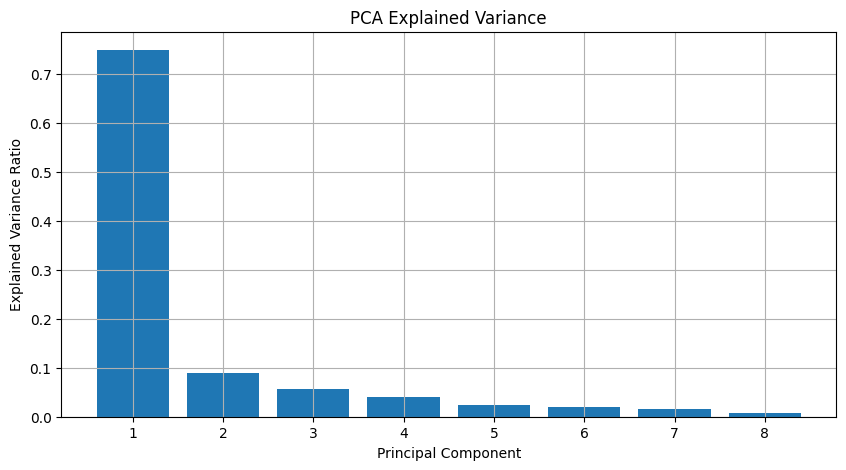

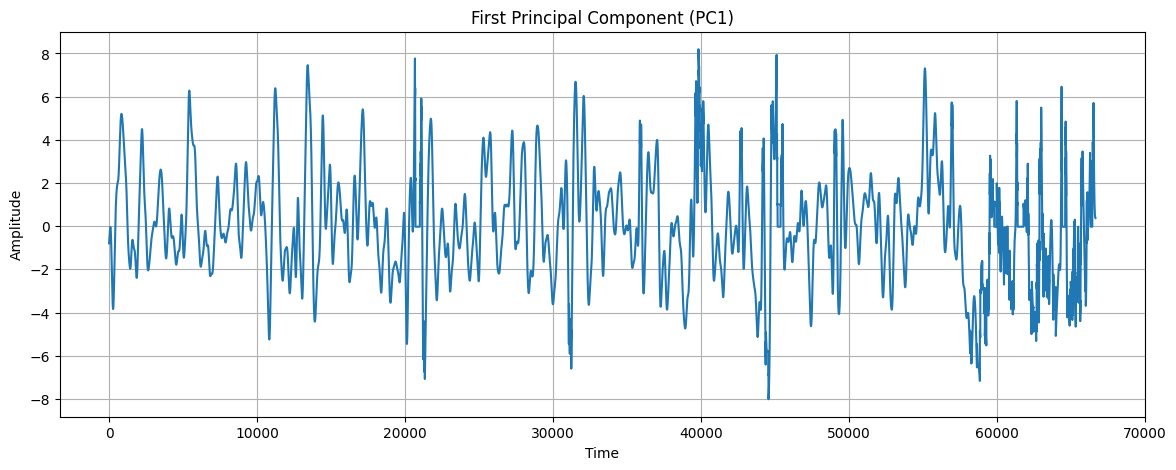

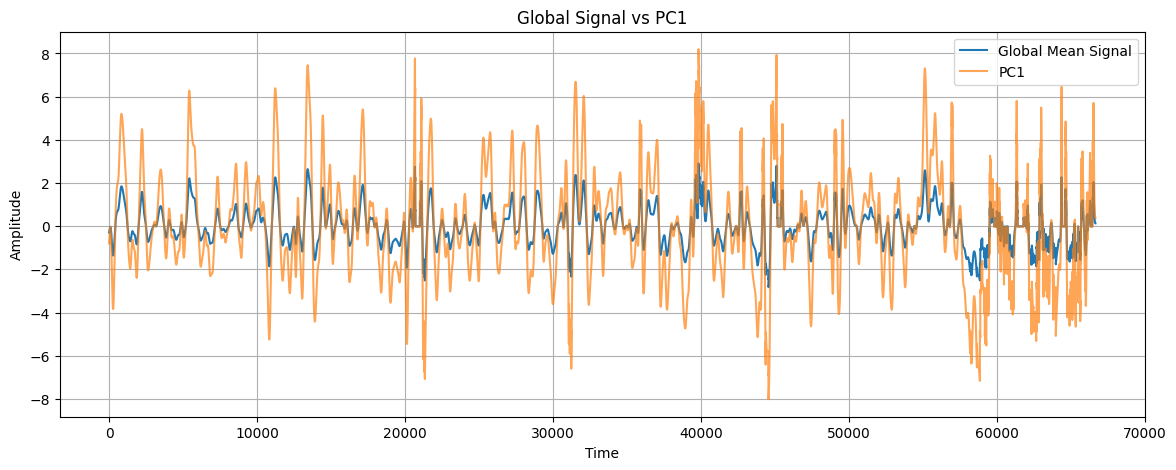

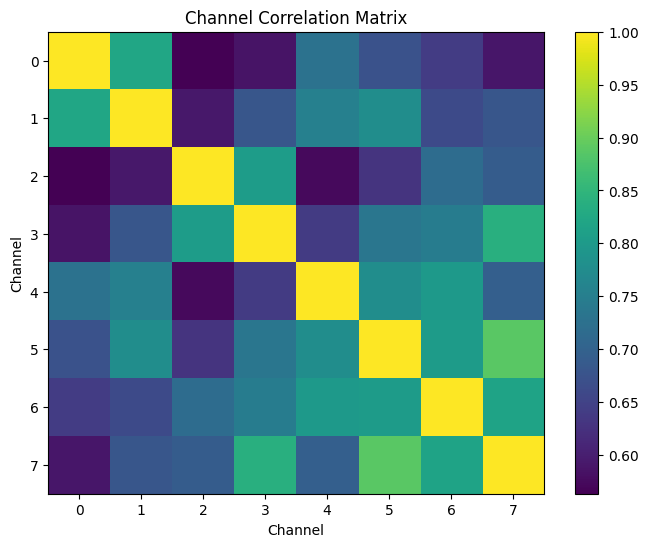

In [72]:
fnirs_data = read_fnirs("sub_01", 1)

fnirs_data = fnirs_data[
    FNIRS_CHANNELS
].values.T

# optional preprocessing first
fnirs_data = preprocess_fnirs(
    fnirs_data,
    fs=FNIRS_FS
)

# =========================================================
# RUN PCA ANALYSIS
# =========================================================

pca, transformed = analyze_fnirs_pca(
    fnirs_data
)

In [77]:
import numpy as np

from scipy.signal import butter
from scipy.stats import median_abs_deviation
from sklearn.decomposition import PCA

from scipy.signal import butter
from scipy.signal import sosfiltfilt

def bandpass_fnirs(
    signal,
    fs=64,
    lowcut=0.01,
    highcut=0.3,
    order=4
):

    signal = np.nan_to_num(
        signal,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    nyquist = fs / 2

    low = lowcut / nyquist
    high = highcut / nyquist

    sos = butter(
        order,
        [low, high],
        btype="bandpass",
        output="sos"
    )

    filtered = sosfiltfilt(
        sos,
        signal
    )

    filtered = np.nan_to_num(
        filtered,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return filtered

def robust_clip(
    signal,
    threshold=5.0
):

    median = np.median(signal)

    mad = median_abs_deviation(
        signal
    )

    if mad == 0:
        mad = 1e-8

    robust_z = (
        signal - median
    ) / mad

    clipped = signal.copy()

    clipped[
        np.abs(robust_z) > threshold
    ] = median

    return clipped


def remove_global_pca(
    fnirs_data
):
    pca = PCA(
        n_components=fnirs_data.shape[0]
    )

    transformed = pca.fit_transform(
        fnirs_data.T
    )

    transformed[:, 0] = 0

    reconstructed = pca.inverse_transform(
        transformed
    ).T

    return reconstructed

def normalize_fnirs(
    fnirs_data
):

    normalized = np.zeros_like(
        fnirs_data
    )

    for ch in range(fnirs_data.shape[0]):

        signal = fnirs_data[ch]

        mean = signal.mean()
        std = signal.std()

        if std == 0:
            std = 1e-8

        normalized[ch] = (
            signal - mean
        ) / std

    return normalized


def preprocess_fnirs(fnirs_data, fs):

    # =====================================================
    # DATAFRAME -> NUMPY
    # =====================================================

    if isinstance(fnirs_data, pd.DataFrame):

        fnirs_data = fnirs_data.values.T

    # shape:
    # (channels, times)

    processed = fnirs_data.copy()

    # =====================================================
    # BANDPASS
    # =====================================================

    for ch in range(processed.shape[0]):

        signal = processed[ch]

        signal = bandpass_fnirs(
            signal,
            fs=fs,
            lowcut=0.01,
            highcut=0.3
        )

        processed[ch] = signal

    # =====================================================
    # PCA
    # =====================================================

    pca = PCA(
        n_components=processed.shape[0]
    )

    transformed = pca.fit_transform(
        processed.T
    )

    # -----------------------------------------------------
    # REMOVE PC1
    # -----------------------------------------------------

    transformed[:, 0] = 0

    # =====================================================
    # RECONSTRUCT
    # =====================================================

    reconstructed = pca.inverse_transform(
        transformed
    )

    # shape:
    # (times, channels)

    reconstructed = reconstructed.T

    return reconstructed

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================


FNIRS_TMIN = 2.0
FNIRS_TMAX = 6.0

FNIRS_FS = 64  # sesuai explanatory data analysis


In [83]:
def build_subject_fnirs(subject, subject_df):

    all_trials = []
    all_labels = []

    sessions = sorted(
        subject_df["session"].unique()
    )

    print(f"\nSubject: {subject}")
    print(f"Sessions: {sessions}")
   

    print(f"Extracting session: {len(sessions)}")
    for session in sessions:

        print(f"Processing session: {session}")
       
        fnirs = read_fnirs(
            subject,
            session
        )
        
        # =====================================================
        # AMBIL CHANNEL DULU
        # =====================================================
        
        fnirs_data = fnirs[
            FNIRS_CHANNELS
        ].values.T
        
        # shape:
        # (channels, times)
        
        # =====================================================
        # PREPROCESS
        # =====================================================
        
        fnirs_data = preprocess_fnirs(
            fnirs_data,
            fs=FNIRS_FS
        )


        session_df = subject_df[
            subject_df["session"] == session
        ]

       

        fnirs_data = fnirs[
            FNIRS_CHANNELS
        ].values.T

   

        for _, row in session_df.iterrows():

            onset_sec = row["onset_sec"]

            label = int(
                row["label"]
            )

          

            start_sample = int(
                (onset_sec + FNIRS_TMIN)
                * FNIRS_FS
            )

            end_sample = int(
                (onset_sec + FNIRS_TMAX)
                * FNIRS_FS
            )

            # ---------------------------------------------
            # SEGMENT
            # ---------------------------------------------

            segment = fnirs_data[
                :,
                start_sample:end_sample
            ]

            expected_len = int(
                (FNIRS_TMAX - FNIRS_TMIN)
                * FNIRS_FS
            )

            # ---------------------------------------------
            # SKIP BROKEN SEGMENT
            # ---------------------------------------------

            if segment.shape[1] != expected_len:
                continue

            all_trials.append(segment)

            all_labels.append(label)

    X_fnirs = np.array(
        all_trials
    )

    y = np.array(
        all_labels
    )

    print("\nFinal Shape:")
    print(X_fnirs.shape)
    print(y.shape)

    return X_fnirs, y

  0%|                                                                                                                                                                                                      | 0/20 [00:00<?, ?it/s]


Processing sub_01

Subject: sub_01
Sessions: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Extracting session: 9
Processing session: 1
Processing session: 2
Processing session: 3
Processing session: 4
Processing session: 5
Processing session: 6
Processing session: 7
Processing session: 8
Processing session: 9

Final Shape:
(324, 8, 256)
(324,)


  5%|█████████▌                                                                                                                                                                                    | 1/20 [00:00<00:17,  1.11it/s]


Processing sub_02

Subject: sub_02
Sessions: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Extracting session: 9
Processing session: 1
Processing session: 2
Processing session: 3
Processing session: 4
Processing session: 5
Processing session: 6
Processing session: 7
Processing session: 8
Processing session: 9


 10%|███████████████████                                                                                                                                                                           | 2/20 [00:01<00:15,  1.17it/s]

...


Processing sub_19

Subject: sub_19
Sessions: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Extracting session: 9
Processing session: 1
Processing session: 2
Processing session: 3
Processing session: 4
Processing session: 5
Processing session: 6
Processing session: 7


 95%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌         | 19/20 [00:12<00:00,  1.55it/s]

Processing session: 8
Processing session: 9

Final Shape:
(319, 8, 256)
(319,)

Processing sub_20

Subject: sub_20
Sessions: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Extracting session: 8
Processing session: 1
Processing session: 2
Processing session: 3
Processing session: 4
Processing session: 5
Processing session: 6
Processing session: 7


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:13<00:00,  1.52it/s]

Processing session: 8

Final Shape:
(285, 8, 256)
(285,)

All Subject Pvalues Shape:
(20, 36)

BEST WINDOW
Time    : 5.149999999999999
P-value : 0.8826489353611938


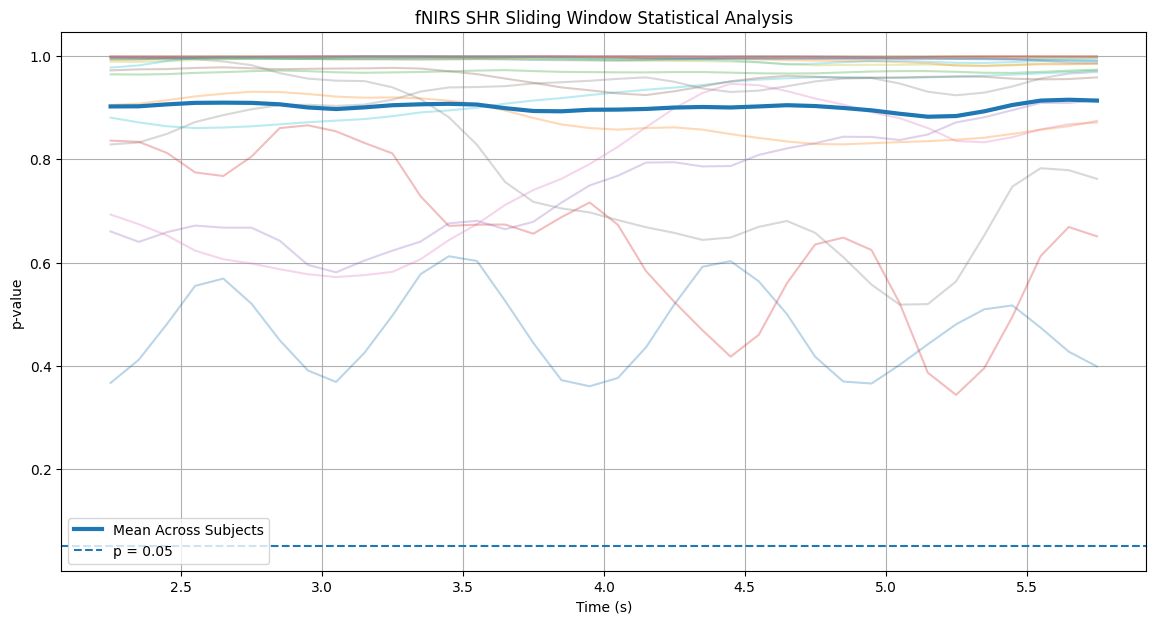

In [84]:

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import f_oneway
from tqdm import tqdm

# =========================================================
# CONFIG
# =========================================================

WINDOW_SIZE = 0.5
STEP_SIZE = 0.1

# =========================================================
# STORAGE
# =========================================================

all_subject_pvalues = []

# =========================================================
# SUBJECT LOOP
# =========================================================

define_auth()
df_train = get_dataset()

subjects = sorted(
    df_train["subject"].unique()
)

for subject in tqdm(subjects):

    print(f"\nProcessing {subject}")

    # =====================================================
    # BUILD SUBJECT FNIRS
    # =====================================================

    X_fnirs, y = build_subject_fnirs(
        subject,
        df_train[
            df_train["subject"] == subject
        ]
    )

    # -----------------------------------------------------
    # TIME AXIS
    # -----------------------------------------------------

    times = np.linspace(
        FNIRS_TMIN,
        FNIRS_TMAX,
        X_fnirs.shape[-1]
    )

    # # =====================================================
    # # SHR VISUALIZATION
    # # =====================================================

    # fig, axes = plt.subplots(
    #     4,
    #     1,
    #     figsize=(12, 10),
    #     sharex=True
    # )

    # for cls in range(4):

    #     class_trials = X_fnirs[
    #         y == cls
    #     ]

    #     # ---------------------------------------------
    #     # SHR
    #     # ---------------------------------------------

    #     shr = class_trials.mean(axis=0)

    #     # ---------------------------------------------
    #     # MEAN CHANNEL
    #     # ---------------------------------------------

    #     shr_mean = shr.mean(axis=0)

    #     axes[cls].plot(
    #         times,
    #         shr_mean
    #     )

    #     axes[cls].set_title(
    #         f"{subject} - SHR Trajectory {cls}"
    #     )

    #     axes[cls].grid()

    # plt.tight_layout()
    # plt.show()

    # =====================================================
    # SLIDING WINDOW P-VALUE
    # =====================================================

    subject_pvalues = []
    center_times = []

    start = FNIRS_TMIN

    while start + WINDOW_SIZE <= FNIRS_TMAX:

        end = start + WINDOW_SIZE

        # -------------------------------------------------
        # WINDOW MASK
        # -------------------------------------------------

        mask = (
            (times >= start)
            &
            (times <= end)
        )

        # -------------------------------------------------
        # FEATURE PER CLASS
        # -------------------------------------------------

        features_per_class = []

        for cls in range(4):

            class_trials = X_fnirs[
                y == cls
            ]

            # ---------------------------------------------
            # WINDOW DATA
            # ---------------------------------------------

            window_data = class_trials[
                :,
                :,
                mask
            ]

            # ---------------------------------------------
            # FEATURE
            # mean all channels + time
            # ---------------------------------------------

            feature = window_data.mean(
                axis=(1, 2)
            )

            features_per_class.append(
                feature
            )

        # -------------------------------------------------
        # ANOVA
        # -------------------------------------------------

        _, p = f_oneway(
            *features_per_class
        )

        subject_pvalues.append(
            p
        )

        center_times.append(
            start + WINDOW_SIZE / 2
        )

        start += STEP_SIZE

    # =====================================================
    # SAVE SUBJECT RESULT
    # =====================================================

    all_subject_pvalues.append(
        subject_pvalues
    )

# =========================================================
# ARRAY
# =========================================================

all_subject_pvalues = np.array(
    all_subject_pvalues
)

# shape:
# (subjects, windows)

print("\nAll Subject Pvalues Shape:")
print(all_subject_pvalues.shape)

# =========================================================
# MEAN P-VALUE
# =========================================================

mean_pvalues = all_subject_pvalues.mean(
    axis=0
)

# =========================================================
# BEST WINDOW
# =========================================================

best_idx = np.argmin(
    mean_pvalues
)

best_time = center_times[
    best_idx
]

best_p = mean_pvalues[
    best_idx
]

print("\nBEST WINDOW")
print("Time    :", best_time)
print("P-value :", best_p)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(14, 7))

# ---------------------------------------------------------
# PER SUBJECT
# ---------------------------------------------------------

for pvals in all_subject_pvalues:

    plt.plot(
        center_times,
        pvals,
        alpha=0.3
    )

# ---------------------------------------------------------
# MEAN
# ---------------------------------------------------------

plt.plot(
    center_times,
    mean_pvalues,
    linewidth=3,
    label="Mean Across Subjects"
)

# ---------------------------------------------------------
# SIGNIFICANCE LINE
# ---------------------------------------------------------

plt.axhline(
    0.05,
    linestyle="--",
    label="p = 0.05"
)

plt.xlabel("Time (s)")
plt.ylabel("p-value")

plt.title(
    "fNIRS SHR Sliding Window Statistical Analysis"
)

plt.legend()

plt.grid()

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import f_oneway

# =========================================================
# CONFIG
# =========================================================

WINDOW_SIZE = 0.5
STEP_SIZE = 0.1

# =========================================================
# TIME AXIS
# =========================================================

times = np.linspace(
    FNIRS_TMIN,
    FNIRS_TMAX,
    X_fnirs.shape[-1]
)

# =========================================================
# STORAGE
# =========================================================

channel_results = {}

# =========================================================
# LOOP CHANNEL
# =========================================================

for ch_idx, ch_name in enumerate(FNIRS_CHANNELS):

    p_values = []
    center_times = []

    # -----------------------------------------------------
    # SLIDING WINDOW
    # -----------------------------------------------------

    start = FNIRS_TMIN

    while start + WINDOW_SIZE <= FNIRS_TMAX:

        end = start + WINDOW_SIZE

        # -------------------------------------------------
        # MASK
        # -------------------------------------------------

        mask = (
            (times >= start)
            &
            (times <= end)
        )

        # -------------------------------------------------
        # FEATURE PER CLASS
        # -------------------------------------------------

        features_per_class = []

        for cls in range(4):

            class_trials = X_fnirs[
                y == cls
            ]

            # shape:
            # (trials, channels, times)

            # ---------------------------------------------
            # CHANNEL DATA
            # ---------------------------------------------

            ch_data = class_trials[
                :,
                ch_idx,
                :
            ]

            # ---------------------------------------------
            # WINDOW DATA
            # ---------------------------------------------

            window_data = ch_data[
                :,
                mask
            ]

            # ---------------------------------------------
            # FEATURE
            # mean amplitude
            # ---------------------------------------------

            feature = window_data.mean(
                axis=1
            )

            features_per_class.append(
                feature
            )

        # -------------------------------------------------
        # ANOVA
        # -------------------------------------------------

        _, p = f_oneway(
            *features_per_class
        )

        p_values.append(p)

        center_times.append(
            start + WINDOW_SIZE / 2
        )

        start += STEP_SIZE

    # =====================================================
    # STORE
    # =====================================================

    channel_results[ch_name] = {
        "times": center_times,
        "p_values": p_values
    }

# =========================================================
# FIND BEST CHANNEL
# =========================================================

best_channel = None
best_time = None
best_p = 999

for ch_name, result in channel_results.items():

    pvals = np.array(
        result["p_values"]
    )

    idx = np.argmin(
        pvals
    )

    min_p = pvals[idx]

    if min_p < best_p:

        best_p = min_p

        best_channel = ch_name

        best_time = result["times"][idx]

print("\nBEST RESULT")
print("Channel :", best_channel)
print("Time    :", best_time)
print("P-value :", best_p)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(14, 7))

for ch_name, result in channel_results.items():

    plt.plot(
        result["times"],
        result["p_values"],
        label=ch_name,
        alpha=0.7
    )

plt.axhline(
    0.05,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("p-value")

plt.title(
    "fNIRS Sliding Window Statistical Analysis"
)

plt.legend()

plt.grid()

plt.show()